In [6]:
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import numpy as np

def plotWrapper(x, y_list, labels=None, xlabel='X-axis', ylabel='Y-axis', title='Plot'):
    # fig, ax = plt.subplots()
    for i, y in enumerate(y_list):
        plt.plot(x, y, label=labels[i] if labels else f"Series {i+1}")
    plt.xlabel(xlabel)  # Use ax to set labels and title
    plt.ylabel(ylabel)
    plt.title(title)

    if labels:
        plt.legend()

    # return current plot
    return plt.gcf()

In [7]:
# Define the parameters for each model
params_HD = {
    'k0': 1.0,
    'k1': 0.5,
    'k12': 0.5,
    'k1_tilda': 0.5,
    'y0_1': [1.5,  0.1]
    
}

params_FK = {
    'alpha': 0.5,
    'y0_1': [0.1]
}


start_time = 0
step_size = 0.4
num_steps  = 100
end_time =  start_time + (step_size * num_steps)

t_span = (start_time, end_time)
t_eval = np.linspace(start_time, end_time - step_size, num_steps)

# solution outputs are
# .t - time
# y[0] - u_1
# y[1] - v_1

In [10]:
from dataclasses import dataclass

@dataclass
class HeterodimerModel:
    nodes: int
    k0: float
    k1: float
    k12: float
    k1_tilda: float
    y0_1: list

    def __post_init__(self):
        assert 0 <= self.k0 <= 1, f"k0 should be between 0 and 1, got {self.k0}"
        assert 0 <= self.k1 <= 1, f"k1 should be between 0 and 1, got {self.k1}"
        assert 0 <= self.k12 <= 1, f"k12 should be between 0 and 1, got {self.k12}"
        assert 0 <= self.k1_tilda <= 1, f"k1_tilda should be between 0 and 1, got {self.k1_tilda}"
        assert self.nodes in [1, 2], f"nodes should be one of [1, 2], got {self.nodes}"

        self.y0 = self.y0_1 * self.nodes # [2.0, 1.0] * 2  = [2.0, 1.0, 2.0, 1.0]
        
        # Returns the appropriate model method based on the number of nodes
        if self.nodes == 1:
            self.modelName = "Heterodimer Single Node Model"
            self.model = self.heterodimer_1_node
        elif self.nodes == 2:
            self.modelName = "Heterodimer Two Node Model"
            self.model = self.heterodimer_2_node
        else:
            raise ValueError("Currently, only models with 1 or 2 nodes are supported.")

    def heterodimer_1_node(self, t, y):
        """Returning single node heterodimer model."""
        u, v = y

        fu = self.k0 - (self.k1 * u) - (self.k12 * u * v)
        fv = - (self.k1_tilda * v) + (self.k12 * u * v)

        return [fu, fv]

    def heterodimer_2_node(self, t, y):
        """Returning Two Node connected by 1 edge"""

        u_1, v_1, u_2, v_2 = y

        fu_1 = -(u_1 - u_2) + self.k0 - (self.k1 * u_1) - (self.k12 * u_1 * v_1)
        fv_1 = -(v_1 - v_2) - (self.k1_tilda * v_1) + (self.k12 * u_1 * v_1)

        fu_2 =  0.0001*u_2 - 0.1*u_1 + self.k0 - (self.k1 * u_2) - (self.k12 * u_2 * v_2) #((0) * (-u_1 + u_2))
        fv_2 =  0.0001*v_2 - 0.1*v_1 - (self.k1_tilda * v_2) + (self.k12 * u_2 * v_2) #((0 ) * (-v_1 + v_2)) 

        return [fu_1, fv_1, fu_2, fv_2]

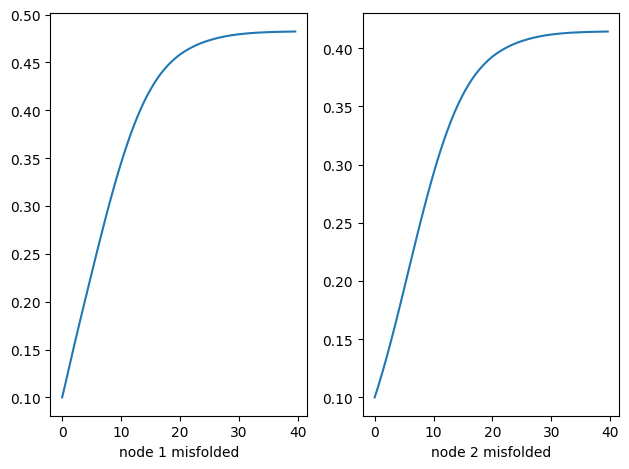

In [12]:
htest_model2 = HeterodimerModel(**params_HD, nodes = 2)

solution_2 = solve_ivp(fun = htest_model2.model, 
                                         t_span = (t_eval[0], t_eval[-1]), 
                                         y0 = htest_model2.y0,
                                         t_eval = t_eval, 
                                         method = 'BDF')

# plot_2 = plotWrapper(solution_2.t, 
#                                   [solution_2.y[1], solution_2.y[3]],
#                                   labels = ['Misfolded Conc. Node 1', 'Misfolded Conc. Node 2'], 
#                                  xlabel = "Time", ylabel = "Concentration", title = htest_model2.modelName)

plt.subplot(1,2,1)
plt.plot(solution_2.t, solution_2.y[1])
plt.xlabel("node 1 misfolded")


plt.subplot(1,2,2)
plt.plot(solution_2.t, solution_2.y[3])
plt.xlabel("node 2 misfolded")

plt.tight_layout()

## Test from here

In [16]:
def heterodimer_2_node(t, y):
    k0 =  1.0
    k1 =  0.5
    k12 =  0.5
    k1_tilda =  0.5
    D = 0.0001
    u_1, v_1, u_2, v_2 = y

    fu_1 =  -1 * D*(u_1 - u_2) + k0 - (k1 * u_1) - (k12 * u_1 * v_1)   # 
    fv_1 =  -1 * D*(v_1 - v_2) - (k1_tilda * v_1) + (k12 * u_1 * v_1)   # 

    fu_2 =  -1 * D*(-u_1 + u_2) + k0 - (k1 * u_2) - (k12 * u_2 * v_2)   # 
    fv_2 =  -1 * D*(-v_1 + v_2) - (k1_tilda * v_2) + (k12 * u_2 * v_2)   # 

    return fu_1, fv_1, fu_2, fv_2
                                             

In [44]:
t = np.linspace(0, 30, 100)

test_solve = solve_ivp(fun = heterodimer_2_node, 
          t_span = [t[0], t[-1]], 
          t_eval = t, 
          y0 = [2.0, 0.1, 2.0, 0.0], method = 'RK45')


# plt.subplot(1,2,1)
# plt.plot(test_solve.t, test_solve.y[1])
# plt.xlabel("node 1 misfolded")


# plt.subplot(1,2,2)
# plt.plot(test_solve.t, test_solve.y[3])
# plt.xlabel("node 2 misfolded")

# plt.tight_layout()

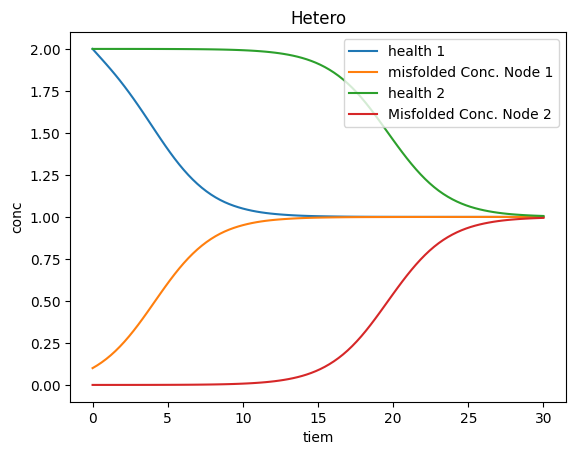

In [46]:
plot_test = plotWrapper(test_solve.t, [ test_solve.y[0], test_solve.y[1], test_solve.y[2], test_solve.y[3]], 
                        labels = ['health 1', 'misfolded Conc. Node 1', 'health 2' ,'Misfolded Conc. Node 2'],
            xlabel = 'tiem', ylabel = 'conc', title = 'Hetero')

### KPP

In [70]:
def fisherKolmogorov_2_node(t, y):
    c_1, c_2 = y
    alpha = 0.5
    D = 1e-4

    fc_1 = -D*(c_1 - c_2)  + (alpha *  c_1 * (1 - c_1))
    fc_2 = -D*(-c_2 + c_2) + (alpha  * c_2 * (1 - c_2))

    return fc_1, fc_2

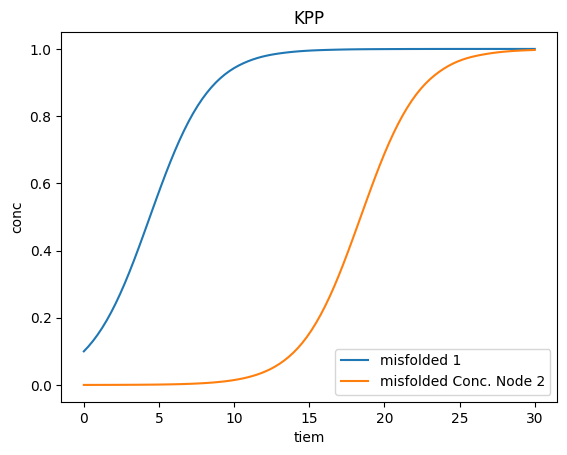

In [77]:
t2 = np.linspace(0, 30, 100)

test_solve2 = solve_ivp(fun = fisherKolmogorov_2_node, 
          t_span = [t2[0], t2[-1]], 
          t_eval = t2, 
          y0 = [0.1, 0.0001], method = 'RK45')

plot_test2 = plotWrapper(test_solve2.t, [ test_solve2.y[0], test_solve2.y[1]], 
                        labels = ['misfolded 1', 'misfolded Conc. Node 2',],
            xlabel = 'tiem', ylabel = 'conc', title = 'KPP')